# AI-ML Assignment 8

## Handwritten Digit Recognition using Artificial Neural Networks (ANN)

**Name:** Prathmesh Chedge

**Registration Number:** 23BEC10046

## Libraries Used

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

%matplotlib inline

## Task 1: Data Understanding

In [6]:
df = pd.read_csv("mnist_train.csv")

In [7]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
print("Dataset Shape:", df.shape)

Dataset Shape: (60000, 785)


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [10]:
target = df.columns[0]
features = df.columns[1:]

print("Target Variable:", target)
print("Number of Input Features:", len(features))
print("First Five Features:", list(features[:5]))

Target Variable: label
Number of Input Features: 784
First Five Features: ['1x1', '1x2', '1x3', '1x4', '1x5']


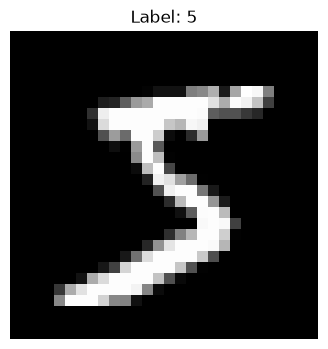

In [11]:
image = df.iloc[0, 1:].values.reshape(28, 28)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(f"Label: {df.iloc[0, 0]}")
plt.axis("off")
plt.show()

## Task 2: Data Preprocessing

In [12]:
print("Missing Values in Dataset:")
print(df.isnull().sum().sum())

Missing Values in Dataset:
0


In [13]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (60000, 784)
Target Shape: (60000,)


In [14]:
X = X / 255.0

print("Minimum Pixel Value:", X.min().min())
print("Maximum Pixel Value:", X.max().max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (48000, 784)
Testing Data: (12000, 784)


In [16]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print("Encoded Training Labels:", y_train.shape)
print("Encoded Testing Labels:", y_test.shape)

Encoded Training Labels: (48000, 10)
Encoded Testing Labels: (12000, 10)


In [17]:
print("One-Hot Encoded Label:")
print(y_train[0])

One-Hot Encoded Label:
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## Task 3: Model Development

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

### Training the Model

In [22]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9218 - loss: 0.2657 - val_accuracy: 0.9588 - val_loss: 0.1390
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9660 - loss: 0.1124 - val_accuracy: 0.9663 - val_loss: 0.1111
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9764 - loss: 0.0766 - val_accuracy: 0.9712 - val_loss: 0.0987
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9817 - loss: 0.0594 - val_accuracy: 0.9732 - val_loss: 0.0892
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9860 - loss: 0.0441 - val_accuracy: 0.9743 - val_loss: 0.0915
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9890 - loss: 0.0356 - val_accuracy: 0.9723 - val_loss: 0.0963
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9902 - loss: 0.0303 - val_accuracy: 0.9740 - val_loss: 0.0968
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9914 - loss: 0.0261 - 

In [23]:
predictions = model.predict(X_test)

predicted_labels = predictions.argmax(axis=1)
actual_labels = y_test.argmax(axis=1)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step


In [24]:
prediction_results = pd.DataFrame({
    "Actual Digit": actual_labels[:10],
    "Predicted Digit": predicted_labels[:10]
})

prediction_results

,Actual Digit,Predicted Digit
0,7,7
1,3,3
2,8,8
3,9,9
4,3,3
5,9,9
6,7,7
7,7,7
8,5,5
9,4,4


## Task 4: Model Evaluation

In [25]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

Test Loss: 0.1138
Test Accuracy: 97.32 %


In [26]:
cm = confusion_matrix(actual_labels, predicted_labels)

print(cm)

[[1165    0    1    0    3    0    2    1    1    2]
 [   0 1315    2    0    0    0    3    0    0    2]
 [   5    7 1148    1    1    0    2    7    1    2]
 [   4    2   28 1155    0   11    0    3    7    9]
 [   3    2    2    0 1133    0    4    1    0   31]
 [   9    1    2    5    2 1066    6    2    5    6]
 [   5    3    0    0    1    1 1165    0    1    1]
 [   0    5    8    0    2    0    0 1275    2    7]
 [  21    4   11    5    3    4    4    2 1088   18]
 [   4    1    1    0    6    2    0   12    0 1168]]


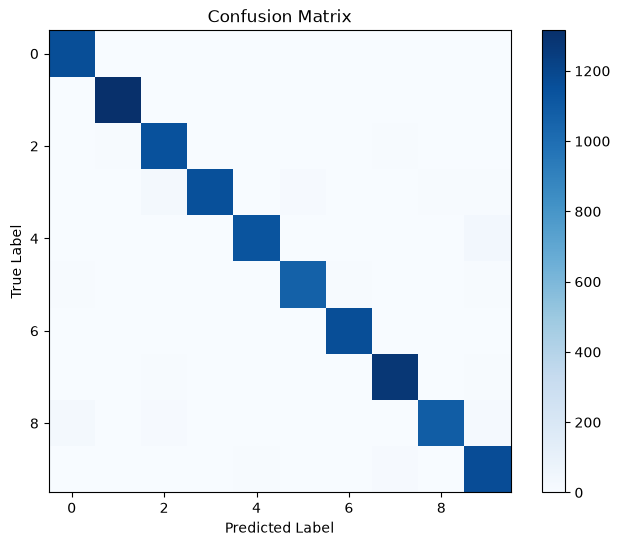

In [31]:
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.savefig("images/confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

In [28]:
print(classification_report(actual_labels, predicted_labels))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1175
           1       0.98      0.99      0.99      1322
           2       0.95      0.98      0.97      1174
           3       0.99      0.95      0.97      1219
           4       0.98      0.96      0.97      1176
           5       0.98      0.97      0.97      1104
           6       0.98      0.99      0.99      1177
           7       0.98      0.98      0.98      1299
           8       0.98      0.94      0.96      1160
           9       0.94      0.98      0.96      1194

    accuracy                           0.97     12000
   macro avg       0.97      0.97      0.97     12000
weighted avg       0.97      0.97      0.97     12000



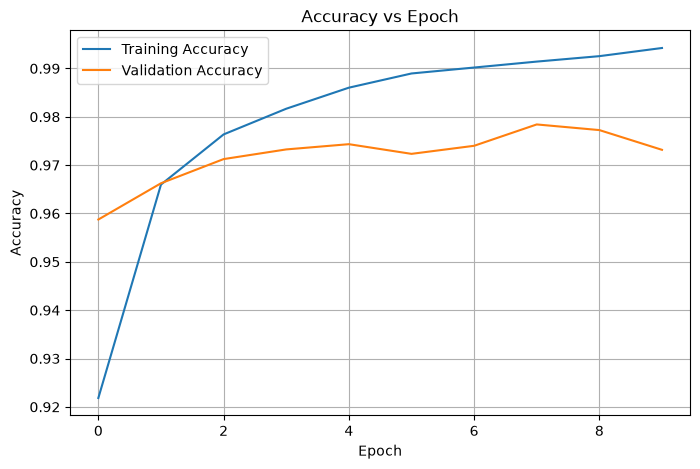

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig("images/accuracy.png", dpi=300, bbox_inches="tight")

plt.show()

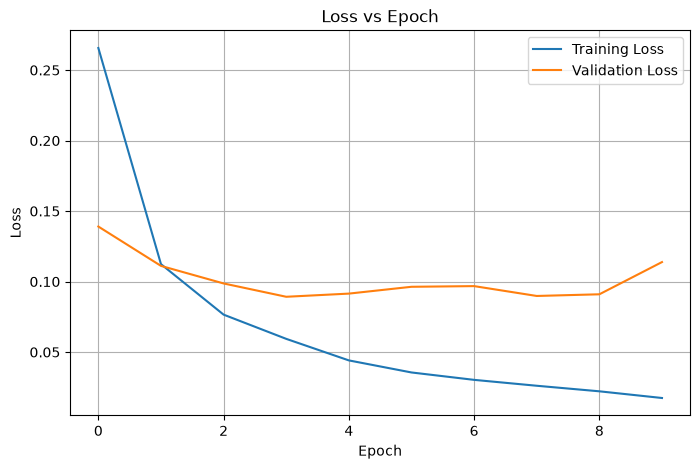

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig("images/loss.png", dpi=300, bbox_inches="tight")

plt.show()

### Observations

1. The ANN achieved a high test accuracy on the MNIST handwritten digit dataset.
2. The training and validation accuracy increased steadily over the 10 epochs.
3. The training and validation loss decreased with each epoch, indicating effective learning.
4. The confusion matrix shows that most handwritten digits were classified correctly, with only a few misclassifications.

## Task 5: Conclusion

In this assignment, an Artificial Neural Network (ANN) was developed to classify handwritten digits using the MNIST dataset. The model was trained for 10 epochs and achieved high accuracy, demonstrating that ANNs are effective for image classification tasks. The hidden layers played an important role by learning meaningful patterns and improving the model's ability to recognize different handwritten digits. One major advantage of Deep Learning over traditional Machine Learning is that it can automatically learn complex features from raw data without requiring manual feature engineering. However, one limitation of ANN is that it requires a large amount of training data and computational resources to achieve good performance. Overall, the model successfully recognized handwritten digits with high accuracy and fulfilled the objectives of the assignment.